<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen028.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

N_grid = 256
x = np.linspace(0, 2*np.pi, N_grid, endpoint=False)
A = 0.1
sigma = 0.2
theta = np.pi / 3
dt = 0.01
gamma = 0.005
lam = 0.1

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

def laplacian(phi):
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def evolve(phi):
    lap = laplacian(phi)
    nonlinear = lam * np.clip(phi, -1.0, 1.0)**3
    phi = phi + dt * (lap - gamma * phi + nonlinear)
    return np.clip(phi, -1.0, 1.0)


In [3]:
ensemble_size = 10
merge_events = []
scatter_events = []
annihilation_events = []

for run in range(ensemble_size):
    centers = np.random.choice(x, size=5, replace=False)
    nodes = [gaussian(c, sigma, A) * np.cos(theta) for c in centers]
    phi = sum(nodes)
    history = [phi.copy()]

    for t in range(300):
        phi = evolve(phi)
        if t % 10 == 0:
            history.append(phi.copy())

    # Track particles
    prev_peaks = None
    for snapshot in history:
        peaks, _ = find_peaks(snapshot, height=0.02)
        if prev_peaks is not None:
            # Merge: fewer peaks than before
            if len(peaks) < len(prev_peaks):
                merge_events.append(1)
            # Scatter: peaks moved > threshold
            elif any(abs(p - q) > 10 for p, q in zip(peaks, prev_peaks)):
                scatter_events.append(1)
            # Annihilation: peak vanished
            elif len(peaks) == 0:
                annihilation_events.append(1)
        prev_peaks = peaks


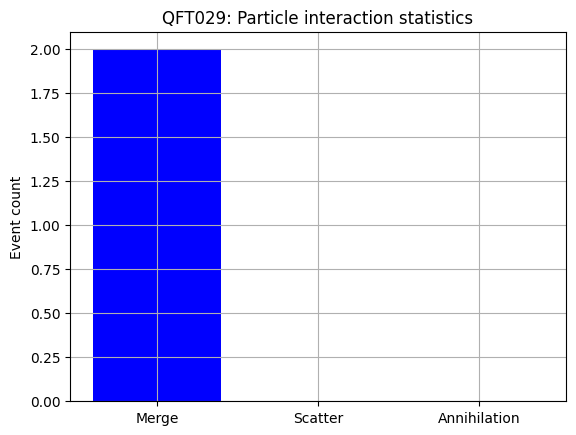

In [4]:
labels = ["Merge", "Scatter", "Annihilation"]
counts = [sum(merge_events), sum(scatter_events), sum(annihilation_events)]

plt.bar(labels, counts, color=["blue", "orange", "red"])
plt.title("QFT029: Particle interaction statistics")
plt.ylabel("Event count")
plt.grid(True)
plt.show()
